In [7]:
import json
import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

### LOAD DATA

In [15]:
path = '../datasets/Entity Recognition in Resumes.json'

records = []
with open(path, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

print(f"Total resume: {len(records)}")
print(f"Record keys: {list(records[0].keys())}")
print(f"\nSample annotation entry:")
print(json.dumps(records[0]['annotation'][0], indent=2))

Total resume: 220
Record keys: ['content', 'annotation', 'extras']

Sample annotation entry:
{
  "label": [
    "Skills"
  ],
  "points": [
    {
      "start": 1295,
      "end": 1621,
      "text": "\n\u2022 Programming language: C, C++, Java\n\u2022 Oracle PeopleSoft\n\u2022 Internet Of Things\n\u2022 Machine Learning\n\u2022 Database Management System\n\u2022 Computer Networks\n\u2022 Operating System worked on: Linux, Windows, Mac\n\nNon - Technical Skills\n\n\u2022 Honest and Hard-Working\n\u2022 Tolerant and Flexible to Different Situations\n\u2022 Polite and Calm\n\u2022 Team-Player"
    }
  ]
}


### Data Overview

In [18]:
rows = []
for idx, record in enumerate(records):
    content = record['content']
    content_len = len(content)
    word_count = len(content.split())
    n_annotations = len(record.get('annotation', []))
    
    for ann in record.get('annotation', []):
        label = ann['label'][0] if ann['label'] else 'UNKNOWN'
        for point in ann.get('points', []):
            rows.append({
                'resume_id': idx,
                'content_length': content_len,
                'word_count': word_count,
                'n_annotations': n_annotations,
                'label': label,
                'entity_text': point.get('text', '').strip(),
                'start': point.get('start'),
                'end': point.get('end'),
            })

df = pd.DataFrame(rows)
df['entity_length'] = df['entity_text'].str.len()
df['entity_word_count'] = df['entity_text'].str.split().str.len()

print(f"Total annotated entity instances: {len(df)}")
print(f"Unique entity labels: {df['label'].nunique()}")
print(f"Unique resumes: {df['resume_id'].nunique()}")
print()
df.head()

Total annotated entity instances: 3558
Unique entity labels: 11
Unique resumes: 220



,resume_id,content_length,word_count,n_annotations,label,entity_text,start,end,entity_length,entity_word_count
0,0,1622,227,14,Skills,"• Programming language: C, C++, Java\n• Oracle...",1295,1621,326,52
1,0,1622,227,14,Skills,"C (Less than 1 year), Database (Less than 1 ye...",993,1153,161,28
2,0,1622,227,14,College Name,Kendriya Vidyalaya,939,956,18,2
3,0,1622,227,14,College Name,Woodbine modern school,883,904,22,3
4,0,1622,227,14,Graduation Year,2017,856,860,4,1


In [21]:
resume_df = pd.DataFrame([{
    'resume_id': idx,
    'content_length': len(r['content']),
    'word_count': len(r['content'].split()),
    'n_annotations': len(r.get('annotation', [])),
} for idx, r in enumerate(records)])

print("Resume-Level Summary")
resume_df[['content_length', 'word_count', 'n_annotations']].describe().round(1)

Resume-Level Summary


,content_length,word_count,n_annotations
count,220.0,220.0,220.0
mean,3697.1,517.8,16.2
std,3275.2,482.3,10.0
min,346.0,29.0,5.0
25%,1402.0,185.5,10.0
50%,2924.0,400.0,13.0
75%,4859.5,680.8,19.0
max,20143.0,2953.0,82.0


### Entity Label Distribution

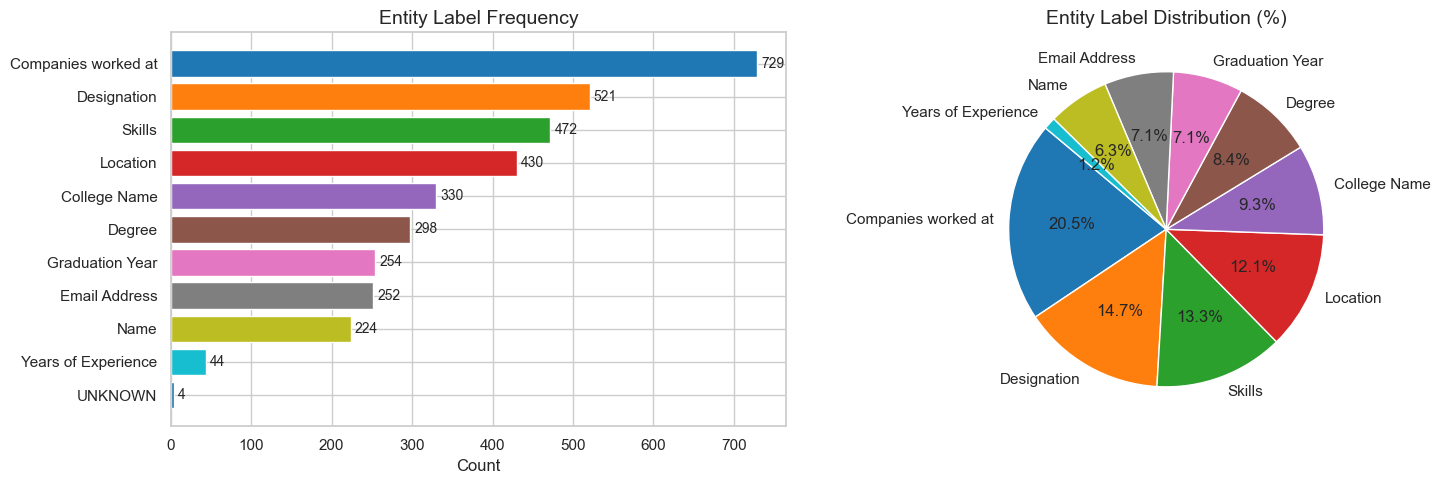


Label counts:
label
Companies worked at    729
Designation            521
Skills                 472
Location               430
College Name           330
Degree                 298
Graduation Year        254
Email Address          252
Name                   224
Years of Experience     44
UNKNOWN                  4


In [22]:
label_counts = df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
colors = sns.color_palette('tab10', len(label_counts))
bars = axes[0].barh(label_counts.index[::-1], label_counts.values[::-1], color=colors[::-1])
axes[0].set_xlabel("Count")
axes[0].set_title("Entity Label Frequency")
for bar, val in zip(bars, label_counts.values[::-1]):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=10)

# Pie chart
# Exclude UNKNOWN from pie
pie_data = label_counts[label_counts.index != 'UNKNOWN']
axes[1].pie(pie_data, labels=pie_data.index, autopct='%1.1f%%',
            startangle=140, colors=colors[:len(pie_data)])
axes[1].set_title("Entity Label Distribution (%)")

plt.tight_layout()
plt.show()

print("\nLabel counts:")
print(label_counts.to_string())

### Resume Content Analysis

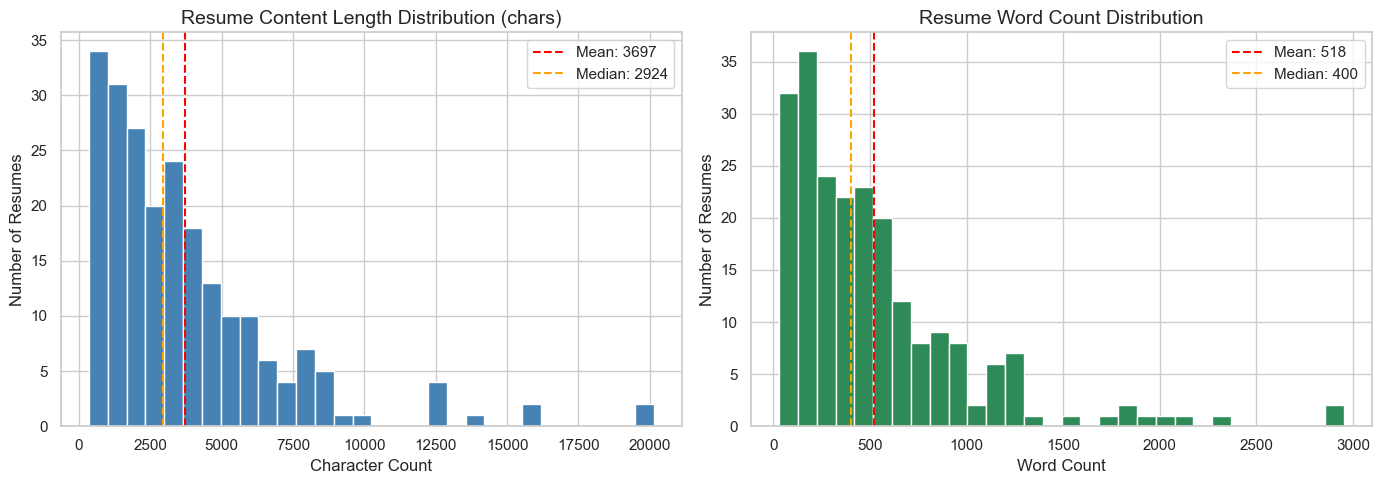

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Content length distribution
axes[0].hist(resume_df['content_length'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(resume_df['content_length'].mean(), color='red', linestyle='--',
                label=f"Mean: {resume_df['content_length'].mean():.0f}")
axes[0].axvline(resume_df['content_length'].median(), color='orange', linestyle='--',
                label=f"Median: {resume_df['content_length'].median():.0f}")
axes[0].set_title("Resume Content Length Distribution (chars)")
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Number of Resumes")
axes[0].legend()

# Word count distribution
axes[1].hist(resume_df['word_count'], bins=30, color='seagreen', edgecolor='white')
axes[1].axvline(resume_df['word_count'].mean(), color='red', linestyle='--',
                label=f"Mean: {resume_df['word_count'].mean():.0f}")
axes[1].axvline(resume_df['word_count'].median(), color='orange', linestyle='--',
                label=f"Median: {resume_df['word_count'].median():.0f}")
axes[1].set_title("Resume Word Count Distribution")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Number of Resumes")
axes[1].legend()

plt.tight_layout()
plt.show()

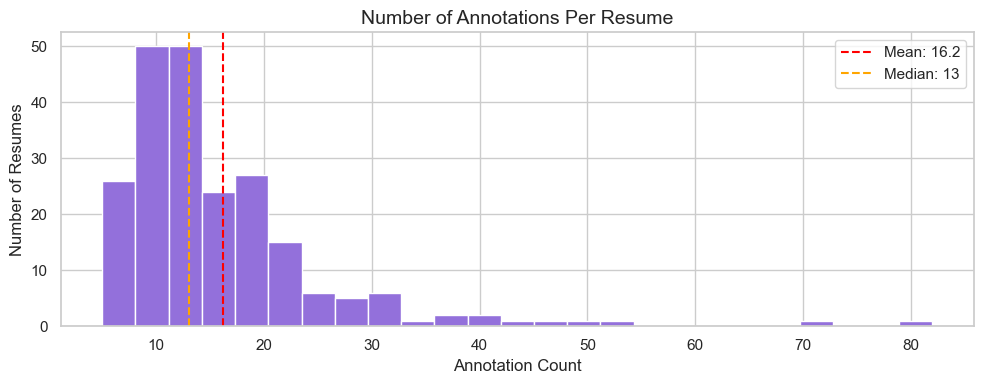

In [24]:
# Annotations per resume distribution
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(resume_df['n_annotations'], bins=25, color='mediumpurple', edgecolor='white')
ax.axvline(resume_df['n_annotations'].mean(), color='red', linestyle='--',
           label=f"Mean: {resume_df['n_annotations'].mean():.1f}")
ax.axvline(resume_df['n_annotations'].median(), color='orange', linestyle='--',
           label=f"Median: {resume_df['n_annotations'].median():.0f}")
ax.set_title("Number of Annotations Per Resume")
ax.set_xlabel("Annotation Count")
ax.set_ylabel("Number of Resumes")
ax.legend()
plt.tight_layout()
plt.show()

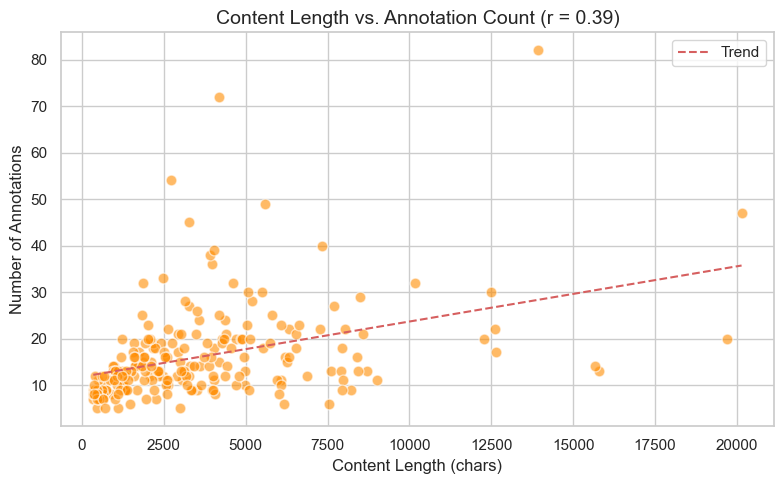

In [25]:
# Correlation: content length vs annotation count
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(resume_df['content_length'], resume_df['n_annotations'],
           alpha=0.6, color='darkorange', edgecolors='white', s=60)
corr = resume_df[['content_length', 'n_annotations']].corr().iloc[0, 1]
ax.set_title(f"Content Length vs. Annotation Count (r = {corr:.2f})")
ax.set_xlabel("Content Length (chars)")
ax.set_ylabel("Number of Annotations")

# Trend line
z = np.polyfit(resume_df['content_length'], resume_df['n_annotations'], 1)
p = np.poly1d(z)
x_line = np.linspace(resume_df['content_length'].min(), resume_df['content_length'].max(), 200)
ax.plot(x_line, p(x_line), 'r--', linewidth=1.5, label='Trend')
ax.legend()
plt.tight_layout()
plt.show()